# Proyecto Final: Telecomunicaciones - Identificación de operadores ineficaces

## 1. Introducción

CallMeMaybe es un servicio de telefonía virtual utilizado por organizaciones que gestionan grandes volúmenes de llamadas entrantes y salientes a través de operadores. Con el fin de mejorar la supervisión del desempeño, la empresa desea desarrollar una herramienta capaz de identificar operadores ineficaces.

Un operador se considera ineficaz cuando presenta una alta cantidad de llamadas perdidas, tiempos de espera prolongados en llamadas entrantes o un bajo volumen de llamadas salientes cuando estas forman parte de sus funciones.

En este proyecto se realizará un análisis exploratorio de los datos disponibles, se establecerán criterios para identificar operadores ineficaces y se validarán los hallazgos mediante pruebas estadísticas.


**Objetivo del proyecto**

Identificar operadores ineficaces dentro del servicio CallMeMaybe mediante el análisis de métricas relacionadas con llamadas perdidas, tiempos de espera y actividad operativa.

Para lograrlo se realizará:

* Exploración y limpieza de datos.
* Análisis exploratorio de llamadas y operadores.
* Definición de criterios de ineficacia.
* Identificación de operadores con bajo desempeño.
* Validación de resultados mediante pruebas de hipótesis estadísticas.


## 2. Carga y exploración de datos

### 2.1 Carga de datasets

In [1]:
import pandas as pd

telecom = pd.read_csv('/datasets/telecom_dataset_us.csv')
clients = pd.read_csv('/datasets/telecom_clients_us.csv')

In [2]:
print('Telecom:', telecom.shape)
print('Clients:', clients.shape)

Telecom: (53902, 9)
Clients: (732, 3)


### 2.2 Exploración inicial de los datos

In [3]:
# Dimensiones de los datasets
telecom.shape
clients.shape

(732, 3)

In [4]:
# Primeras filas
telecom.head()
clients.head()

,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


In [5]:
# Información general
telecom.info()
clients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    object
 2 

In [6]:
# Estadísticas descriptivas
telecom.describe()

,user_id,operator_id,calls_count,call_duration,total_call_duration
count,53902.000000,45730.000000,53902.000000,53902.000000,53902.000000
mean,167295.344477,916535.993002,16.451245,866.684427,1157.133297
std,598.883775,21254.123136,62.917170,3731.791202,4403.468763
min,166377.000000,879896.000000,1.000000,0.000000,0.000000
25%,166782.000000,900788.000000,1.000000,0.000000,47.000000
50%,167162.000000,913938.000000,4.000000,38.000000,210.000000
75%,167819.000000,937708.000000,12.000000,572.000000,902.000000
max,168606.000000,973286.000000,4817.000000,144395.000000,166155.000000


In [7]:
clients.describe(include='all')

,user_id,tariff_plan,date_start
count,732.000000,732,732
unique,NaN,3,73
top,NaN,C,2019-09-24
freq,NaN,395,24
mean,167431.927596,NaN,NaN
std,633.810383,NaN,NaN
min,166373.000000,NaN,NaN
25%,166900.750000,NaN,NaN
50%,167432.000000,NaN,NaN
75%,167973.000000,NaN,NaN


La exploración inicial permitió conocer la estructura y características generales de los datasets. 

El conjunto principal contiene 53.902 registros y 9 variables relacionadas con llamadas telefónicas, mientras que el dataset de clientes contiene 732 registros y 3 variables. 

Se identificó la presencia de variables numéricas, categóricas y booleanas, así como posibles valores ausentes en algunas columnas. Además, se observó que las variables de fecha se encuentran almacenadas como tipo objeto y requerirán conversión a formato datetime durante la preparación de los datos.

### 2.3 Calidad de los datos

In [8]:
# Valores ausentes
telecom.isna().sum()

user_id                   0
date                      0
direction                 0
internal                117
operator_id            8172
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
dtype: int64

In [9]:
clients.isna().sum()

user_id        0
tariff_plan    0
date_start     0
dtype: int64

Se identificaron valores ausentes únicamente en el dataset telecom. La columna internal presenta 117 valores faltantes, mientras que operator_id contiene 8.172 registros sin información. 

El resto de las variables no presenta valores ausentes. En el dataset clients no se encontraron valores faltantes. Posteriormente se analizará el significado de estos registros para determinar si corresponden a información faltante real o a características propias del proceso de registro de llamadas.

In [10]:
# Duplicados
telecom.duplicated().sum()

4900

In [11]:
clients.duplicated().sum()

0

Se identificaron 4.900 registros duplicados en el dataset telecom, mientras que el dataset clients no presenta registros duplicados. 

Debido a que esta cantidad representa una proporción considerable del conjunto de datos, será necesario analizar estos registros antes de eliminarlos para determinar si corresponden a duplicados reales o si forman parte del comportamiento esperado de las llamadas registradas por el sistema.

In [12]:
# Conversión
telecom['date'] = pd.to_datetime(telecom['date'])

clients['date_start'] = pd.to_datetime(clients['date_start'])

In [13]:
telecom.info()
clients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype                                
---  ------               --------------  -----                                
 0   user_id              53902 non-null  int64                                
 1   date                 53902 non-null  datetime64[ns, pytz.FixedOffset(180)]
 2   direction            53902 non-null  object                               
 3   internal             53785 non-null  object                               
 4   operator_id          45730 non-null  float64                              
 5   is_missed_call       53902 non-null  bool                                 
 6   calls_count          53902 non-null  int64                                
 7   call_duration        53902 non-null  int64                                
 8   total_call_duration  53902 non-null  int64                                
dtypes: bool

Se observó que las variables date y date_start se encontraban almacenadas como tipo objeto. Ambas columnas fueron convertidas al formato datetime para facilitar el análisis temporal y permitir operaciones relacionadas con fechas durante las siguientes etapas del proyecto.

### 2.4 Preparación de datos

In [14]:
# Paso 1: Revisar los duplicados

telecom[telecom.duplicated()].head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
8,166377,2019-08-05 00:00:00+03:00,out,False,880020.0,True,8,0,50
28,166377,2019-08-12 00:00:00+03:00,in,False,NaN,True,2,0,34
44,166377,2019-08-14 00:00:00+03:00,out,False,880026.0,False,10,1567,1654
45,166377,2019-08-14 00:00:00+03:00,in,False,NaN,True,1,0,3
51,166377,2019-08-15 00:00:00+03:00,out,False,880026.0,False,11,1413,1473


In [15]:
telecom[telecom.duplicated()].shape

(4900, 9)

In [16]:
# Eliminando duplicados
telecom = telecom.drop_duplicates()

In [17]:
telecom.duplicated().sum()

0

In [18]:
# Verificación
telecom.shape

(49002, 9)

Se identificaron 4.900 registros duplicados en el dataset telecom. Tras verificar que correspondían a duplicados completos, se procedió a eliminarlos para evitar distorsiones en los resultados del análisis. 

Después de la depuración, el conjunto de datos quedó conformado por 49.002 registros.

In [19]:
# Paso 2 : Análisis de valores ausentes
telecom[telecom['operator_id'].isna()].head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
7,166377,2019-08-05 00:00:00+03:00,in,False,NaN,True,6,0,35
9,166377,2019-08-06 00:00:00+03:00,in,False,NaN,True,4,0,62
17,166377,2019-08-07 00:00:00+03:00,in,False,NaN,True,2,0,24
27,166377,2019-08-12 00:00:00+03:00,in,False,NaN,True,2,0,34


In [20]:
# Validación
telecom[telecom['operator_id'].isna()]['is_missed_call'].value_counts()

True     7343
False     113
Name: is_missed_call, dtype: int64

In [21]:
telecom[
    (telecom['operator_id'].isna()) &
    (telecom['is_missed_call'] == False)
].head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
698,166399,2019-08-12 00:00:00+03:00,in,False,NaN,False,1,10,55
704,166399,2019-09-02 00:00:00+03:00,in,False,NaN,False,1,68,115
4089,166503,2019-09-26 00:00:00+03:00,out,False,NaN,False,1,213,220
4136,166503,2019-10-09 00:00:00+03:00,in,False,NaN,False,1,374,405
4198,166503,2019-10-21 00:00:00+03:00,out,True,NaN,False,2,382,397


Se identificaron 7.456 registros con valores ausentes en la columna operator_id. La revisión mostró que 7.343 de ellos corresponden a llamadas perdidas, mientras que 113 registros no presentan esta condición. 

Debido a que los valores faltantes podrían contener información relevante para la identificación de operadores ineficaces, se realizará una inspección más detallada antes de decidir su tratamiento

In [22]:
telecom[telecom['internal'].isna()].head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
1007,166405,2019-09-18 00:00:00+03:00,in,NaN,NaN,True,1,0,59
1090,166405,2019-10-01 00:00:00+03:00,in,NaN,NaN,True,1,0,1
1864,166406,2019-08-20 00:00:00+03:00,in,NaN,NaN,True,1,0,36
1924,166406,2019-09-02 00:00:00+03:00,in,NaN,879898.0,False,1,2,9
6210,166541,2019-09-26 00:00:00+03:00,in,NaN,908960.0,False,1,393,423


In [23]:
# Validación 
telecom['internal'].value_counts(dropna=False)

False    43239
True      5653
NaN        110
Name: internal, dtype: int64

In [24]:
# Paso 3: Limpieza de datos
# Eliminar registros sin operador
telecom = telecom.dropna(subset=['operator_id'])


In [25]:
# Eliminar registros sin información de internal
telecom = telecom.dropna(subset=['internal'])

In [26]:
# Verificación
telecom.isna().sum()

user_id                0
date                   0
direction              0
internal               0
operator_id            0
is_missed_call         0
calls_count            0
call_duration          0
total_call_duration    0
dtype: int64

Se identificaron y eliminaron 4.900 registros duplicados en el dataset telecom. 

Además, se analizaron los valores ausentes presentes en las columnas operator_id e internal. Dado que el objetivo del proyecto es evaluar el desempeño de los operadores, los registros sin identificador de operador fueron excluidos del análisis. 

Los pocos valores faltantes restantes en la variable internal también fueron eliminados debido a su baja proporción. Finalmente, se corrigieron los tipos de datos de las variables de fecha y se verificó que el conjunto de datos quedara sin valores ausentes.

## 3. Análisis Exploratorio de Datos (EDA)

### 3.1 Distribución de llamadas por dirección

El objetivo es entender cómo se distribuyen las llamadas entre entrantes (in) y salientes (out), ya que la definición de operador ineficaz depende en parte del manejo de ambos tipos de llamadas.

In [27]:
# Distribución de llamadas por dirección
telecom['direction'].value_counts()

out    28813
in     12678
Name: direction, dtype: int64

In [28]:
# Distribución porcentual
telecom['direction'].value_counts(normalize=True) * 100

out    69.443976
in     30.556024
Name: direction, dtype: float64

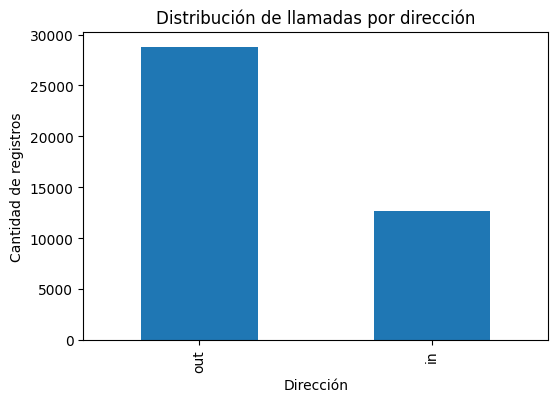

In [29]:
# Gráfico
import matplotlib.pyplot as plt

telecom['direction'].value_counts().plot(
    kind='bar',
    figsize=(6,4)
)

plt.title('Distribución de llamadas por dirección')
plt.xlabel('Dirección')
plt.ylabel('Cantidad de registros')
plt.show()

La mayoría de los registros corresponden a llamadas salientes (out), con 28.813 registros, equivalentes al 69,44% del total. Por su parte, las llamadas entrantes (in) representan 12.678 registros, es decir, el 30,56%.

Esta distribución indica que el servicio es utilizado principalmente para realizar llamadas salientes. Este hallazgo es relevante para el análisis posterior, ya que uno de los criterios para identificar operadores ineficaces está relacionado con la baja actividad en llamadas salientes. Además, será necesario considerar que los indicadores asociados a llamadas entrantes y salientes no tendrán el mismo peso debido a la diferencia en volumen entre ambos tipos de llamadas.

## 3.2 Distribución de llamadas internas y externas

Ahora vamos a analizar la variable internal:

 - True = llamada interna (entre operadores de una misma empresa)
 - False = llamada externa (con clientes o contactos externos)

In [30]:
# Distribución de llamadas internas y externas
telecom['internal'].value_counts()

False    36161
True      5330
Name: internal, dtype: int64

In [31]:
# Distribución porcentual
telecom['internal'].value_counts(normalize=True) * 100

False    87.153841
True     12.846159
Name: internal, dtype: float64

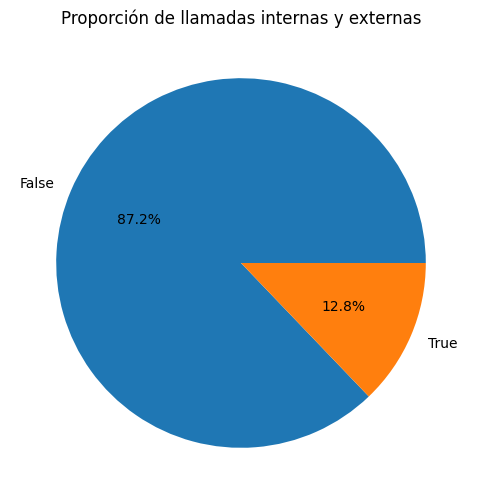

In [32]:
telecom['internal'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title('Proporción de llamadas internas y externas')
plt.ylabel('')
plt.show()

La mayor parte de las llamadas registradas corresponden a comunicaciones externas (internal = False), con 36.161 registros, equivalentes al 87,15% del total. Por otro lado, las llamadas internas (internal = True) representan únicamente 5.330 registros, es decir, el 12,85%.

Esto indica que el servicio es utilizado principalmente para la comunicación con clientes o contactos externos, mientras que las interacciones entre operadores representan una proporción considerablemente menor. Este hallazgo es relevante para el objetivo del proyecto, ya que los indicadores de eficiencia estarán influenciados principalmente por el manejo de llamadas externas, que constituyen la mayor parte de la actividad registrada.

### 3.3 Análisis de llamadas perdidas

In [33]:
# Distribución de llamadas perdidas
telecom['is_missed_call'].value_counts()

False    27382
True     14109
Name: is_missed_call, dtype: int64

In [34]:
# Porcentaje de llamadas perdidas
telecom['is_missed_call'].value_counts(normalize=True) * 100

False    65.995035
True     34.004965
Name: is_missed_call, dtype: float64

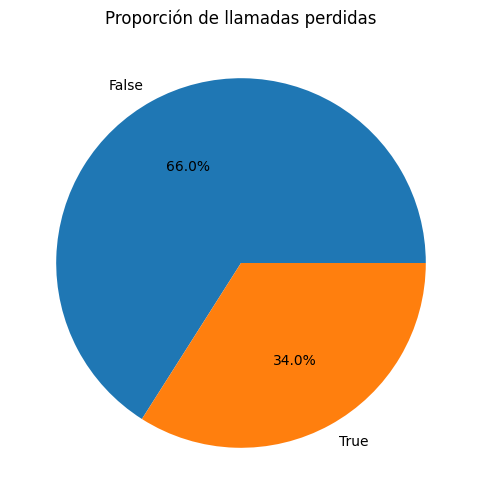

In [35]:
telecom['is_missed_call'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title('Proporción de llamadas perdidas')
plt.ylabel('')
plt.show()

Del total de registros analizados, 14.109 corresponden a llamadas perdidas, lo que representa el 34,00% de todas las llamadas registradas. Por otro lado, 27.382 llamadas (66,00%) fueron atendidas correctamente.

La proporción de llamadas perdidas resulta considerablemente alta, ya que aproximadamente una de cada tres llamadas no fue atendida. Este resultado es especialmente relevante para el objetivo del proyecto, debido a que uno de los principales criterios para identificar operadores ineficaces es la presencia de un elevado número de llamadas perdidas, particularmente en las llamadas entrantes.

Por lo tanto, será necesario profundizar en el análisis de las llamadas perdidas a nivel de operador para determinar si existen diferencias significativas en el desempeño de los distintos operadores.

### 3.4 Duración de las llamadas

In [36]:
# Estadísticas de duración
telecom[['call_duration', 'total_call_duration']].describe()

,call_duration,total_call_duration
count,41491.000000,41491.000000
mean,1010.940011,1323.153238
std,4066.666485,4788.953155
min,0.000000,0.000000
25%,0.000000,67.000000
50%,106.000000,289.000000
75%,772.000000,1107.000000
max,144395.000000,166155.000000


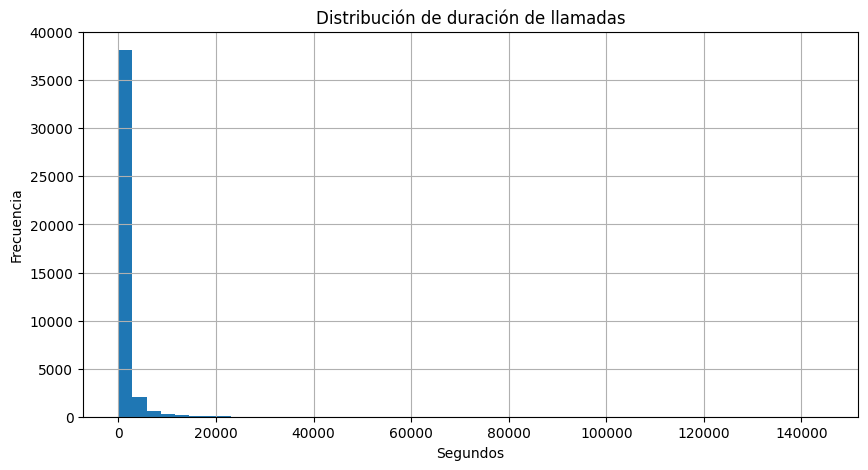

In [37]:
# Histogramas
import matplotlib.pyplot as plt

telecom['call_duration'].hist(
    bins=50,
    figsize=(10,5)
)

plt.title('Distribución de duración de llamadas')
plt.xlabel('Segundos')
plt.ylabel('Frecuencia')
plt.show()

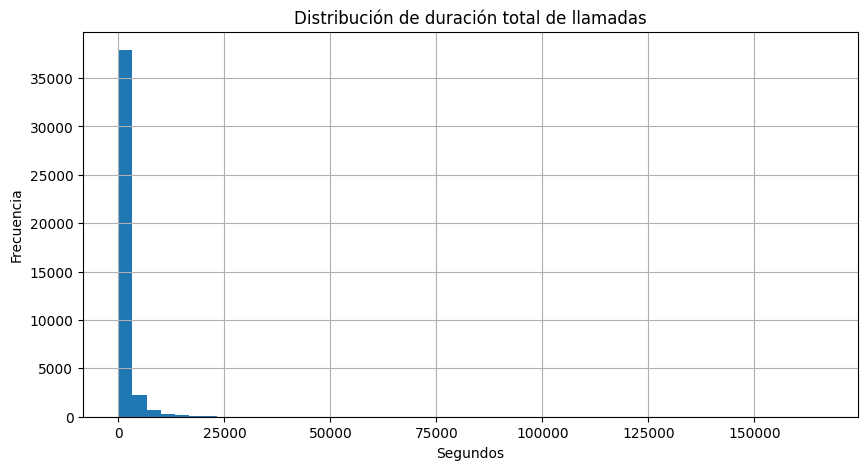

In [38]:
telecom['total_call_duration'].hist(
    bins=50,
    figsize=(10,5)
)

plt.title('Distribución de duración total de llamadas')
plt.xlabel('Segundos')
plt.ylabel('Frecuencia')
plt.show()

Las variables call_duration y total_call_duration presentan una distribución fuertemente sesgada hacia la derecha. La mayoría de las llamadas tienen duraciones relativamente cortas, mientras que existe un pequeño grupo de llamadas con duraciones extremadamente altas.

La duración promedio de las llamadas es de aproximadamente 1.011 segundos, mientras que la mediana es de solo 106 segundos. De forma similar, la duración total promedio es de 1.323 segundos frente a una mediana de 289 segundos. Esta diferencia entre media y mediana confirma la presencia de valores atípicos que elevan considerablemente el promedio.

Los histogramas muestran una alta concentración de llamadas de corta duración y una larga cola hacia valores elevados, alcanzando máximos de 144.395 segundos para call_duration y 166.155 segundos para total_call_duration.

Debido a esta asimetría, para análisis posteriores será más apropiado utilizar medidas robustas como la mediana o percentiles, especialmente al evaluar el desempeño de los operadores.

### 3.5 Análisis del tiempo de espera

In [39]:
telecom['waiting_time'] = (
    telecom['total_call_duration']
    - telecom['call_duration']
)

In [40]:
telecom['waiting_time'].describe()

count    41491.000000
mean       312.213227
std       1176.102940
min          0.000000
25%         19.000000
50%         60.000000
75%        219.000000
max      46474.000000
Name: waiting_time, dtype: float64

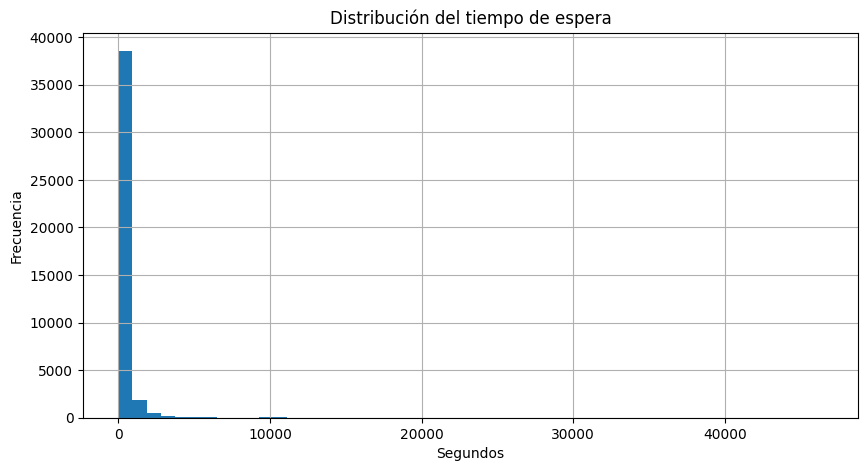

In [41]:
telecom['waiting_time'].hist(
    bins=50,
    figsize=(10,5)
)

plt.title('Distribución del tiempo de espera')
plt.xlabel('Segundos')
plt.ylabel('Frecuencia')
plt.show()

Se calculó el tiempo de espera como la diferencia entre la duración total de la llamada y la duración efectiva de conversación.

El tiempo de espera presenta una distribución altamente asimétrica hacia la derecha. La mayoría de las llamadas tienen tiempos de espera relativamente bajos, mientras que existe un pequeño grupo de casos con tiempos de espera extremadamente altos.

La media del tiempo de espera es de 312 segundos, mientras que la mediana es de solo 60 segundos, lo que indica una fuerte influencia de valores atípicos. El 75% de las observaciones presenta tiempos de espera inferiores a 219 segundos.

El valor máximo registrado alcanza 46.474 segundos, lo que evidencia la existencia de casos excepcionales que podrían corresponder a situaciones operativas particulares o anomalías en el sistema.

Debido a esta distribución sesgada, la mediana será una medida más adecuada que la media para evaluar el desempeño típico de los operadores en relación con los tiempos de espera.

### 3.6 Actividad por operador

In [42]:
# Número de operadores únicos

telecom['operator_id'].nunique()

1092

In [43]:
# Llamadas por operador

calls_per_operator = (
    telecom.groupby('operator_id')['calls_count']
    .sum()
    .sort_values(ascending=False)
)

calls_per_operator.head(10)

operator_id
885890.0    60221
885876.0    59429
929428.0    23754
925922.0    20021
908640.0    14239
929426.0    11189
879898.0     7312
945286.0     6880
945302.0     6138
893804.0     5846
Name: calls_count, dtype: int64

In [44]:
# Estadísticas de llamadas por operador

calls_per_operator.describe()

count     1092.000000
mean       642.934982
std       2889.647014
min          1.000000
25%         10.000000
50%         72.000000
75%        493.750000
max      60221.000000
Name: calls_count, dtype: float64

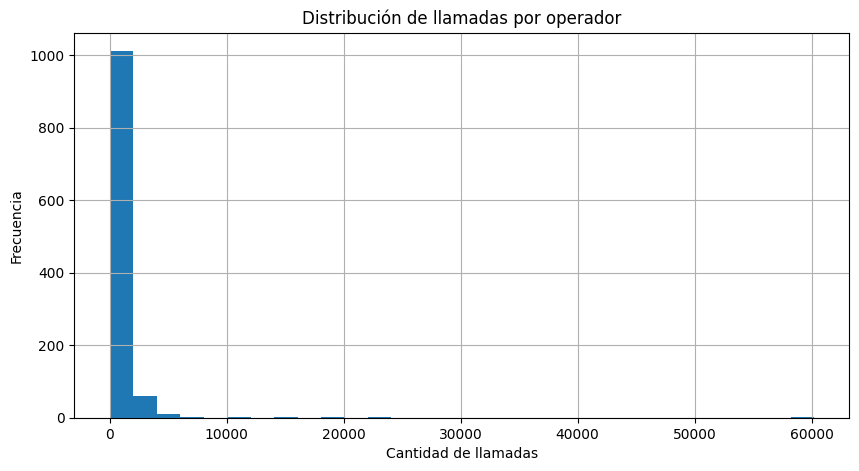

In [45]:
# Histograma

calls_per_operator.hist(
    bins=30,
    figsize=(10,5)
)

plt.title('Distribución de llamadas por operador')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()

Se identificaron 1.092 operadores únicos en el conjunto de datos.

La distribución de llamadas gestionadas por operador presenta una fuerte asimetría hacia la derecha. Mientras algunos operadores gestionan decenas de miles de llamadas, la mayoría maneja volúmenes mucho más reducidos.

El operador con mayor actividad registra 60.221 llamadas, seguido por otros operadores con más de 20.000 llamadas. Sin embargo, la mediana es de apenas 72 llamadas por operador, lo que indica que más de la mitad de los operadores gestionaron menos de 72 llamadas durante el período analizado.

El primer cuartil muestra que el 25% de los operadores gestionó 10 llamadas o menos, mientras que el tercer cuartil indica que el 75% gestionó menos de 494 llamadas.

El histograma confirma la existencia de un pequeño grupo de operadores con una actividad extremadamente alta y una gran cantidad de operadores con niveles bajos de actividad. Esta diferencia deberá considerarse al momento de identificar operadores ineficaces, ya que no todos los operadores tienen la misma carga de trabajo.

### 3.7 Indicadores de desempeño por operador

De acuerdo con la descripción del proyecto, un operador puede considerarse ineficaz cuando presenta una alta cantidad de llamadas perdidas, tiempos de espera elevados en llamadas entrantes o una baja actividad en llamadas salientes.

En esta sección se explorarán estas métricas a nivel de operador para identificar patrones generales antes de construir una clasificación formal de operadores ineficaces.

#### 3.7.1 Llamadas perdidas por operador

In [46]:
# Llamadas perdidas por operador

missed_calls_operator = (
    telecom[telecom['is_missed_call'] == True]
    .groupby('operator_id')['calls_count']
    .sum()
    .sort_values(ascending=False)
)

missed_calls_operator.head(10)

operator_id
885890.0    23807
885876.0    23330
929428.0    19118
925922.0     9258
908640.0     8164
929426.0     6347
945286.0     3626
945302.0     3184
919364.0     2688
879898.0     2360
Name: calls_count, dtype: int64

In [47]:
missed_calls_operator.describe()

count      876.000000
mean       310.865297
std       1418.354220
min          1.000000
25%          6.000000
50%         34.000000
75%        229.000000
max      23807.000000
Name: calls_count, dtype: float64

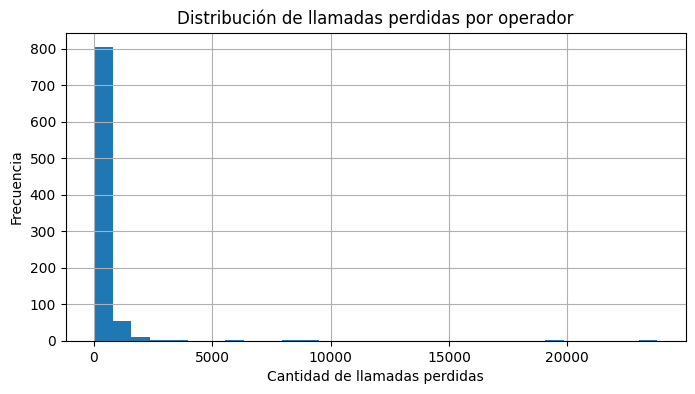

In [48]:
plt.figure(figsize=(8,4))

missed_calls_operator.hist(bins=30)

plt.title('Distribución de llamadas perdidas por operador')
plt.xlabel('Cantidad de llamadas perdidas')
plt.ylabel('Frecuencia')

plt.show()

La cantidad de llamadas perdidas presenta una distribución altamente asimétrica. Aunque la mayoría de los operadores registran pocas llamadas perdidas, existe un grupo reducido que concentra valores extremadamente altos. 

Esta variabilidad sugiere que la tasa de llamadas perdidas puede ser un criterio útil para detectar operadores potencialmente ineficaces en etapas posteriores del análisis.

#### 3.7.2 Tiempo de espera promedio por operador

In [49]:
# Tiempo promedio de espera por operador

waiting_operator = (
    telecom.groupby('operator_id')['waiting_time']
    .mean()
    .sort_values(ascending=False)
)

waiting_operator.head(10)

operator_id
925922.0    5805.027397
885890.0    5703.565217
929428.0    5478.123077
885876.0    4838.459364
908640.0    3537.860465
929426.0    3338.790323
945278.0    2965.590909
919364.0    2804.390244
945286.0    2178.177419
945904.0    2073.459459
Name: waiting_time, dtype: float64

In [50]:
waiting_operator.describe()

count    1092.000000
mean      216.249892
std       507.052815
min         0.000000
25%        23.000000
50%        46.619048
75%       159.758929
max      5805.027397
Name: waiting_time, dtype: float64

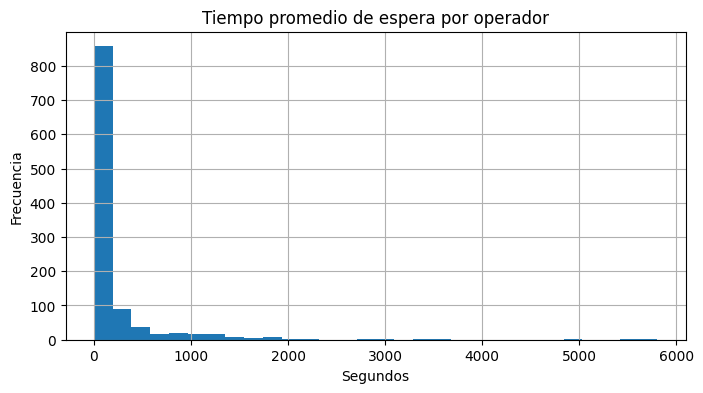

In [51]:
plt.figure(figsize=(8,4))

waiting_operator.hist(bins=30)

plt.title('Tiempo promedio de espera por operador')
plt.xlabel('Segundos')
plt.ylabel('Frecuencia')

plt.show()

El tiempo promedio de espera por operador presenta una distribución altamente asimétrica. Aunque la mediana es de apenas 46.6 segundos y el 75% de los operadores mantiene tiempos de espera inferiores a 160 segundos, existe un grupo reducido de operadores con tiempos extremadamente altos que elevan el promedio general hasta 216 segundos.

Los valores máximos superan los 5.800 segundos de espera promedio, lo que indica que algunos operadores tardan considerablemente más en atender las llamadas entrantes. Dado que uno de los criterios para definir la ineficacia es un tiempo de espera prolongado, esta métrica será fundamental para identificar operadores con bajo desempeño en las siguientes etapas del análisis.

#### 3.7.3 Actividad saliente por operador

In [52]:
# Llamadas salientes por operador

outgoing_calls = (
    telecom[telecom['direction'] == 'out']
    .groupby('operator_id')['calls_count']
    .sum()
    .sort_values(ascending=False)
)

outgoing_calls.head(10)

operator_id
885890.0    58977
885876.0    58437
929428.0    23754
925922.0    19603
908640.0    14239
929426.0    11189
879898.0     7209
945286.0     6880
945302.0     6138
919364.0     4820
Name: calls_count, dtype: int64

In [53]:
outgoing_calls.describe()

count      882.000000
mean       689.731293
std       3122.953946
min          1.000000
25%         11.000000
50%         90.000000
75%        597.250000
max      58977.000000
Name: calls_count, dtype: float64

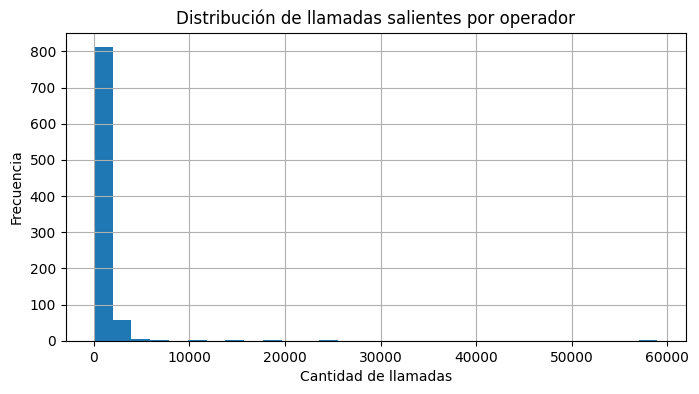

In [54]:
plt.figure(figsize=(8,4))

outgoing_calls.hist(bins=30)

plt.title('Distribución de llamadas salientes por operador')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')

plt.show()

La cantidad de llamadas salientes por operador presenta una distribución altamente desigual. Aunque la mayoría de los operadores registra volúmenes moderados o bajos de llamadas salientes, existe un grupo reducido que concentra una cantidad excepcionalmente alta de actividad.

Dado que la definición de operador ineficaz considera un bajo número de llamadas salientes cuando estas forman parte de sus responsabilidades, esta métrica será utilizada posteriormente junto con las llamadas perdidas y los tiempos de espera para identificar operadores con posible bajo desempeño.

**Conclusiones del análisis exploratorio**

- La mayoría de las llamadas son salientes.
- Las llamadas externas predominan sobre las internas.
- Aproximadamente un tercio de las llamadas registradas son perdidas.
- Las distribuciones de duración y tiempo de espera presentan una fuerte asimetría positiva.
- Existe una gran variabilidad en la actividad entre operadores.
- Algunos operadores concentran cantidades excepcionalmente altas de llamadas perdidas y tiempos de espera.
- Estos indicadores sugieren que es posible identificar operadores potencialmente ineficaces utilizando métricas de llamadas perdidas, tiempo de espera y volumen de llamadas salientes.

## 4. Definición e Identificación de operadores ineficaces

De acuerdo con los objetivos del proyecto, un operador puede considerarse ineficaz cuando presenta:

- Una cantidad elevada de llamadas perdidas.
- Tiempos de espera prolongados en llamadas entrantes.
- Un volumen reducido de llamadas salientes cuando estas forman parte de sus funciones.

Para identificar estos operadores se utilizarán métricas calculadas a nivel de operador y se establecerán umbrales basados en la distribución observada de los datos.

### 4.1 Construcción de métricas por operador

In [55]:
# tabla de métricas
operator_metrics = telecom.groupby('operator_id').agg({
    'calls_count':'sum',
    'waiting_time':'mean'
}).reset_index()

operator_metrics.columns = [
    'operator_id',
    'total_calls',
    'avg_waiting_time'
]

operator_metrics.head()

,operator_id,total_calls,avg_waiting_time
0,879896.0,930,104.914530
1,879898.0,7312,459.690265
2,880020.0,45,14.000000
3,880022.0,197,53.971429
4,880026.0,2232,121.978022


In [56]:
# Llamadas Perdidas
missed_calls = (
    telecom[telecom['is_missed_call'] == True]
    .groupby('operator_id')['calls_count']
    .sum()
    .reset_index()
)

missed_calls.columns = [
    'operator_id',
    'missed_calls'
]

operator_metrics = operator_metrics.merge(
    missed_calls,
    on='operator_id',
    how='left'
)

operator_metrics['missed_calls'] = (
    operator_metrics['missed_calls']
    .fillna(0)
)

In [57]:
# llamadas salientes
outgoing_calls = (
    telecom[telecom['direction'] == 'out']
    .groupby('operator_id')['calls_count']
    .sum()
    .reset_index()
)

outgoing_calls.columns = [
    'operator_id',
    'outgoing_calls'
]

operator_metrics = operator_metrics.merge(
    outgoing_calls,
    on='operator_id',
    how='left'
)

operator_metrics['outgoing_calls'] = (
    operator_metrics['outgoing_calls']
    .fillna(0)
)

In [58]:
# Verificación Resultado
operator_metrics.head()

,operator_id,total_calls,avg_waiting_time,missed_calls,outgoing_calls
0,879896.0,930,104.914530,251.0,872.0
1,879898.0,7312,459.690265,2360.0,7209.0
2,880020.0,45,14.000000,22.0,38.0
3,880022.0,197,53.971429,105.0,189.0
4,880026.0,2232,121.978022,648.0,2208.0


In [59]:
# Revisión estadísticas
operator_metrics.describe()

,operator_id,total_calls,avg_waiting_time,missed_calls,outgoing_calls
count,1092.000000,1092.000000,1092.000000,1092.000000,1092.000000
mean,925517.543956,642.934982,216.249892,249.375458,557.090659
std,22854.532209,2889.647014,507.052815,1276.239677,2819.492227
min,879896.000000,1.000000,0.000000,0.000000,0.000000
25%,906393.500000,10.000000,23.000000,1.000000,2.000000
50%,925105.000000,72.000000,46.619048,14.000000,33.000000
75%,944211.500000,493.750000,159.758929,135.000000,355.250000
max,973286.000000,60221.000000,5805.027397,23807.000000,58977.000000


**Conclusiones preliminares sobre las métricas por operador**

Se construyó una tabla de métricas agregadas por operador para evaluar su desempeño. Las estadísticas descriptivas muestran una alta variabilidad entre operadores en todas las métricas analizadas.

- El 50% de los operadores gestionó 72 llamadas o menos, mientras que algunos operadores registraron más de 60.000 llamadas.
  
- El tiempo promedio de espera presenta una distribución muy asimétrica. La mediana es de aproximadamente 47 segundos, pero existen operadores con tiempos promedio superiores a 5.800 segundos.

- La cantidad de llamadas perdidas también muestra una fuerte concentración en pocos operadores. El 75% de los operadores registra hasta 135 llamadas perdidas, mientras que algunos superan las 23.000.

- La actividad saliente también es desigual: el 50% de los operadores realizó 33 llamadas salientes o menos, mientras que algunos alcanzan casi 59.000.

Estos resultados sugieren la presencia de operadores con comportamientos significativamente distintos al resto de la distribución. Por ello, se utilizarán percentiles para establecer criterios objetivos de identificación de operadores potencialmente ineficaces.

### 4.2 Operadores con tiempos de espera elevados

In [60]:
# Operadores con problemas de espera
operator_metrics['high_waiting'] = (
    operator_metrics['avg_waiting_time'] >
    operator_metrics['avg_waiting_time'].quantile(0.75)
)

In [61]:
operator_metrics['high_waiting'].value_counts()

False    819
True     273
Name: high_waiting, dtype: int64

Se identificaron los operadores cuyo tiempo promedio de espera supera el percentil 75 de la distribución. Estos operadores presentan tiempos de espera significativamente superiores a los observados en la mayoría de los operadores y constituyen un posible grupo de bajo desempeño.

### 4.3 Operadores con alta cantidad de llamadas perdidas

In [62]:
# Operadores con muchas llamadas perdidas
operator_metrics['high_missed_calls'] = (
    operator_metrics['missed_calls'] >
    operator_metrics['missed_calls'].quantile(0.75)
)

In [63]:
operator_metrics['high_missed_calls'].value_counts()

False    821
True     271
Name: high_missed_calls, dtype: int64

Se identificaron los operadores con una cantidad de llamadas perdidas superior al percentil 75. Este grupo representa a los operadores con mayores dificultades para gestionar las llamadas entrantes y constituye uno de los principales indicadores de ineficiencia definidos en el proyecto.

 ### 4.4 Operadores con pocas llamadas salientes

In [64]:
operator_metrics['low_outgoing_calls'] = (
    operator_metrics['outgoing_calls'] <
    operator_metrics['outgoing_calls'].quantile(0.25)
)

In [65]:
operator_metrics['low_outgoing_calls'].value_counts()

False    821
True     271
Name: low_outgoing_calls, dtype: int64

Se identificaron los operadores cuya cantidad de llamadas salientes se encuentra por debajo del percentil 25. Una baja actividad saliente puede ser un indicador adicional de ineficiencia cuando las funciones del operador incluyen la realización de llamadas.

### 4.5 Identificación final de operadores ineficaces

In [66]:
# Indicador de ineficiencia
operator_metrics['inefficient_operator'] = (
    operator_metrics['high_waiting'] |
    operator_metrics['high_missed_calls'] |
    operator_metrics['low_outgoing_calls']
)

In [67]:
operator_metrics['inefficient_operator'].value_counts()

True     596
False    496
Name: inefficient_operator, dtype: int64

Para identificar operadores ineficaces se construyó un indicador basado en los criterios definidos en el proyecto: tiempos de espera elevados, una gran cantidad de llamadas perdidas y un bajo número de llamadas salientes. Un operador fue clasificado como ineficiente si cumplía al menos una de estas condiciones.

Los resultados muestran que 596 operadores fueron identificados como ineficientes, mientras que 496 no presentaron señales significativas de ineficiencia. Esto indica que una proporción importante de los operadores presenta oportunidades de mejora en la gestión de llamadas.

Estos hallazgos permiten enfocar el análisis posterior en los operadores con mayor riesgo de bajo desempeño y proporcionan una base para evaluar estadísticamente las diferencias entre operadores eficientes e ineficientes.


## 5. Pruebas de hipótesis estadísticas

En esta sección se evaluará mediante pruebas estadísticas si existen diferencias significativas entre operadores eficientes e ineficientes. El objetivo es validar si las métricas utilizadas para identificar la ineficiencia reflejan diferencias reales en el desempeño de los operadores.

### 5.1 Comparación inicial entre operadores eficientes e ineficientes

Antes de realizar las pruebas estadísticas, se analizarán las principales métricas de desempeño para los grupos de operadores eficientes e ineficientes.

In [68]:
operator_metrics.groupby('inefficient_operator')[
    ['avg_waiting_time', 'missed_calls', 'outgoing_calls']
].describe()

avg_waiting_time                                          \
                                count        mean         std  min        25%   
inefficient_operator                                                            
False                           496.0   43.816956   33.160783  0.0  20.461725   
True                            596.0  359.751127  651.995966  0.0  26.958333   

                                                          missed_calls  \
                             50%         75%          max        count   
inefficient_operator                                                     
False                  33.491935   55.651786   159.250000        496.0   
True                  125.159579  377.725175  5805.027397        596.0   

                                  ...                  outgoing_calls  \
                            mean  ...     75%      max          count   
inefficient_operator              ...                                   
False                  25.372984  ...   35.00    135.0          496.0   
True                  435.793624  ...  437.25  23807.0          596.0   

                                                                         \
                            mean          std  min  25%    50%      75%   
inefficient_operator                                                      
False                  75.078629    96.939718  2.0  9.0   29.0   105.50   
True                  958.228188  3770.105979  0.0  0.0  104.5  1109.75   

                               
                          max  
inefficient_operator           
False                   474.0  
True                  58977.0  

[2 rows x 24 columns]

In [69]:
efficient = operator_metrics[
    operator_metrics['inefficient_operator'] == False
]

inefficient = operator_metrics[
    operator_metrics['inefficient_operator'] == True
]

print('Operadores eficientes:', len(efficient))
print('Operadores ineficientes:', len(inefficient))

Operadores eficientes: 496
Operadores ineficientes: 596


Se identificaron 596 operadores clasificados como ineficientes y 496 operadores eficientes.

Al comparar ambos grupos, se observan diferencias importantes en las métricas analizadas. Los operadores ineficientes presentan un tiempo de espera promedio considerablemente mayor (359.75 segundos frente a 43.82 segundos), así como una mayor cantidad de llamadas perdidas (435.79 frente a 25.37).

Además, los operadores ineficientes registran una mayor variabilidad en todas las métricas, lo que indica la presencia de casos extremos y comportamientos menos consistentes.

Estos resultados sugieren que los criterios utilizados para identificar la ineficiencia reflejan diferencias reales en el desempeño de los operadores, aunque será necesario confirmarlo mediante pruebas estadísticas.

### 5.2 Hipótesis 1: Tiempo de espera promedio

Se evaluará si existen diferencias significativas en el tiempo de espera promedio entre operadores eficientes e ineficientes.

H₀: No existen diferencias significativas en el tiempo de espera promedio entre operadores eficientes e ineficientes.

H₁: Existen diferencias significativas en el tiempo de espera promedio entre operadores eficientes e ineficientes.

In [70]:
# Introducción e hipótesis
efficient['avg_waiting_time'].describe()

count    496.000000
mean      43.816956
std       33.160783
min        0.000000
25%       20.461725
50%       33.491935
75%       55.651786
max      159.250000
Name: avg_waiting_time, dtype: float64

In [71]:
inefficient['avg_waiting_time'].describe()

count     596.000000
mean      359.751127
std       651.995966
min         0.000000
25%        26.958333
50%       125.159579
75%       377.725175
max      5805.027397
Name: avg_waiting_time, dtype: float64

Los operadores ineficientes presentan tiempos de espera promedio considerablemente más altos que los operadores eficientes. Además, la diferencia entre las medidas de tendencia central y los valores máximos observados sugiere una distribución asimétrica con presencia de valores extremos.

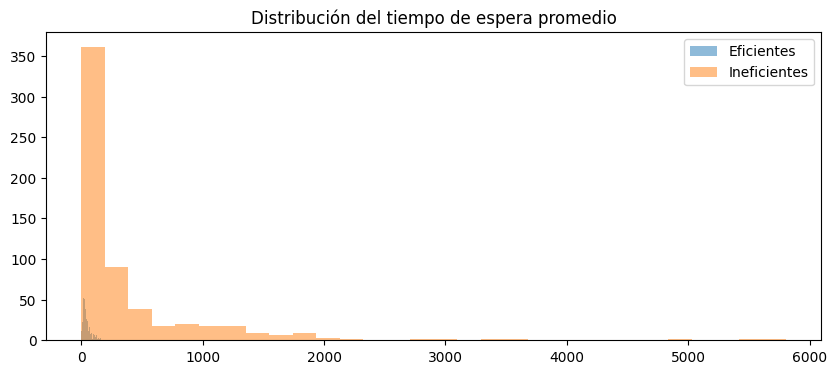

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.hist(
    efficient['avg_waiting_time'],
    bins=30,
    alpha=0.5,
    label='Eficientes'
)

plt.hist(
    inefficient['avg_waiting_time'],
    bins=30,
    alpha=0.5,
    label='Ineficientes'
)

plt.legend()
plt.title('Distribución del tiempo de espera promedio')
plt.show()

La distribución de los tiempos de espera promedio presenta una marcada asimetría positiva en ambos grupos. Además, se observan valores extremos, especialmente entre los operadores ineficientes, donde algunos tiempos de espera alcanzan valores considerablemente altos.

Debido a que los datos no siguen una distribución normal, se utilizará una prueba no paramétrica (Mann-Whitney U) para comparar ambos grupos.

**Prueba de Hipótesis 1**

In [73]:
from scipy.stats import mannwhitneyu

stat, p_value = mannwhitneyu(
    efficient['avg_waiting_time'],
    inefficient['avg_waiting_time'],
    alternative='two-sided'
)

print('Estadístico:', stat)
print('p-value:', p_value)

Estadístico: 87050.5
p-value: 1.148433798574495e-31


**Resultados**

La prueba de Mann-Whitney U arrojó un p-value de 1.15e-31, valor significativamente menor que el nivel de significancia establecido (α = 0.05).

Por lo tanto, se rechaza la hipótesis nula.

**Conclusión**

Existe evidencia estadísticamente significativa para afirmar que los tiempos de espera promedio difieren entre operadores eficientes e ineficientes.

Este resultado respalda el criterio utilizado para identificar operadores ineficaces, ya que los operadores clasificados como ineficientes presentan tiempos de espera considerablemente más altos.

### 5.3 Hipótesis 2: Cantidad de llamadas perdidas

Se evaluará si existen diferencias significativas en la cantidad de llamadas perdidas entre operadores eficientes e ineficientes.

H₀: No existen diferencias significativas en la cantidad de llamadas perdidas entre operadores eficientes e ineficientes.

H₁: Existen diferencias significativas en la cantidad de llamadas perdidas entre operadores eficientes e ineficientes.

In [74]:
# Estadísticas descriptivas
efficient['missed_calls'].describe()

count    496.000000
mean      25.372984
std       30.331635
min        0.000000
25%        4.000000
50%       12.000000
75%       35.000000
max      135.000000
Name: missed_calls, dtype: float64

In [75]:
inefficient['missed_calls'].describe()

count      596.000000
mean       435.793624
std       1705.626928
min          0.000000
25%          0.000000
50%         55.000000
75%        437.250000
max      23807.000000
Name: missed_calls, dtype: float64

Los operadores ineficientes presentan una cantidad de llamadas perdidas considerablemente mayor que los operadores eficientes.

Mientras que los operadores eficientes tienen un promedio de 25.37 llamadas perdidas, los operadores ineficientes alcanzan un promedio de 435.79 llamadas perdidas. Además, la presencia de valores máximos muy elevados y la gran diferencia entre la mediana y la media sugieren una distribución asimétrica con valores extremos.

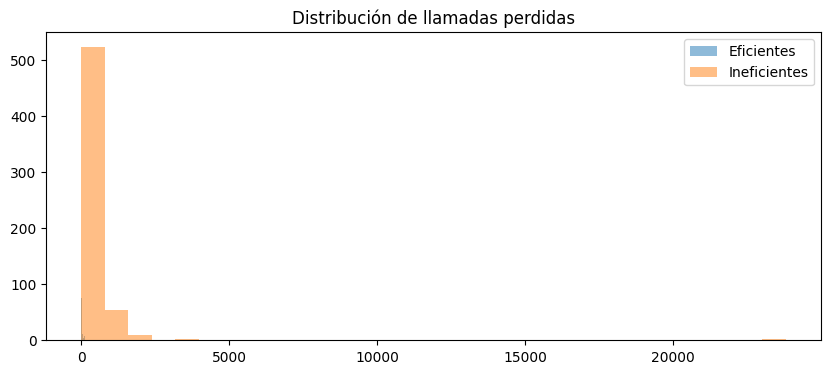

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.hist(
    efficient['missed_calls'],
    bins=30,
    alpha=0.5,
    label='Eficientes'
)

plt.hist(
    inefficient['missed_calls'],
    bins=30,
    alpha=0.5,
    label='Ineficientes'
)

plt.legend()
plt.title('Distribución de llamadas perdidas')
plt.show()

La distribución de las llamadas perdidas presenta una fuerte asimetría positiva y valores extremos, especialmente en el grupo de operadores ineficientes. Debido a que los datos no siguen una distribución normal, se utilizará nuevamente la prueba no paramétrica Mann-Whitney U para comparar ambos grupos.

**Prueba Hipotesis 2**

In [77]:
from scipy.stats import mannwhitneyu

stat, p_value = mannwhitneyu(
    efficient['missed_calls'],
    inefficient['missed_calls'],
    alternative='two-sided'
)

print('Estadístico:', stat)
print('p-value:', p_value)

Estadístico: 133185.5
p-value: 0.004659647461077878


**Resultados**

La prueba de Mann-Whitney U arrojó un p-value de 0.00466, valor menor que el nivel de significancia establecido (α = 0.05).

Por lo tanto, se rechaza la hipótesis nula.

**Conclusión**

Existe evidencia estadísticamente significativa para afirmar que la cantidad de llamadas perdidas difiere entre operadores eficientes e ineficientes.

Los operadores clasificados como ineficientes presentan una cantidad significativamente mayor de llamadas perdidas, lo que respalda el criterio utilizado para identificarlos.

### 5.4 Conclusión general de las pruebas estadísticas

Las pruebas de hipótesis realizadas muestran diferencias estadísticamente significativas entre operadores eficientes e ineficientes tanto en el tiempo de espera promedio como en la cantidad de llamadas perdidas.

En ambos casos se rechazó la hipótesis nula utilizando la prueba no paramétrica Mann-Whitney U, debido a la presencia de distribuciones asimétricas y valores extremos en los datos.

Estos resultados confirman que los criterios utilizados para identificar operadores ineficaces están respaldados por evidencia estadística y permiten distinguir grupos con diferencias reales en su desempeño.

## 6. Conclusiones y recomendaciones

El análisis realizado permitió identificar operadores ineficaces utilizando tres criterios principales: 

  - Tiempos de espera elevados.
  - Alta cantidad de llamadas perdidas.
  - Bajo número de llamadas salientes.

Los resultados muestran que una proporción importante de operadores presenta comportamientos asociados con ineficiencia operativa. Los operadores clasificados como ineficientes registran tiempos de espera significativamente mayores y una mayor cantidad de llamadas perdidas en comparación con los operadores eficientes.

Las pruebas estadísticas confirmaron que estas diferencias son estadísticamente significativas, respaldando la validez de los criterios utilizados para identificar operadores ineficaces.

Como recomendación, la empresa podría implementar mecanismos de monitoreo continuo para detectar operadores con altos tiempos de espera o elevados niveles de llamadas perdidas. Asimismo, sería útil desarrollar indicadores de desempeño que permitan a los supervisores actuar de manera preventiva y mejorar la calidad del servicio ofrecido a los clientes.

En conclusión, la metodología propuesta permite identificar de forma objetiva a los operadores con menor desempeño y puede servir como base para futuras herramientas de monitoreo y toma de decisiones dentro de CallMeMaybe.

## 7. Fuentes consultadas

1. Documentación oficial de Pandas.
2. Documentación oficial de NumPy.
3. Documentación oficial de Matplotlib.
4. Documentación oficial de Seaborn.
5. Documentación oficial de SciPy.
6. Documentación oficial de Tableau Public.
7. Materiales de TripleTen sobre análisis exploratorio de datos.
8. Materiales de TripleTen sobre pruebas de hipótesis estadísticas.

## 8. Dashboard y Presentación

In [78]:
# Exportando archivo para dashboard
operator_metrics.to_csv(
    'operator_metrics.csv',
    index=False
)

print("Archivo exportado correctamente")

Archivo exportado correctamente


El dashboard fue desarrollado en Tableau Public para visualizar los principales indicadores asociados con la eficiencia operativa de los operadores.

Enlace al dashboard:
https://public.tableau.com/views/DashboardProyecto_Final_AO/Desempeodeoperadores?:language=en-US&publish=yes&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link

Enlace a la presentación:
https://drive.google.com/drive/folders/1NmR9NWrccQ7F-ATXoETVWab46QmVLgYc?usp=drive_link